# Assignment 4 — A small GPT

group submission, GPT from scratch course. builds a tiny GPT with our own
attention (no `nn.MultiheadAttention`, no `nn.Transformer`), trains it on
the tiny shakespeare corpus we already had a BPE tokenizer for, and
compares it against the count n-gram and neural n-gram from the earlier
assignments.

seed is fixed with `torch.manual_seed`, see below. `FORCE_RETRAIN` at the
top can be flipped to `False` once we have saved models, but on a fresh
checkout it should just train everything, it fits comfortably under the
time budget on CPU.


In [1]:
import time
import math
import json
import random

import numpy as np
import torch
import matplotlib.pyplot as plt

from bpe import BPETokenizer
from evaluation import perplexity, generate
from ngram import CountNgram, NeuralNgram, train_neural_ngram
from gpt import GPT, train as train_gpt

SEED = 1337
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("using device:", device)

FORCE_RETRAIN = True  # set False once models are cached, we did not bother caching them


using device: cpu


## Data

same shakespeare split idea as assignment 2/3 (90/5/5 train/val/test on
the char stream, then we BPE-encode each split separately so nothing from
val/test leaks into the merges). the WSJ file is the wall street journal
test set we already had lying around from assignment 3 (word-tokenized,
numbers replaced by `N`, all lowercase — that's just how it came).


In [2]:
with open("data/shakespeare.txt", "r", encoding="utf-8") as f:
    shakespeare_text = f.read()

with open("data/wsj_test.txt", "r", encoding="utf-8") as f:
    wsj_text = f.read()

n = len(shakespeare_text)
i1 = int(n * 0.9)
i2 = int(n * 0.95)
train_text = shakespeare_text[:i1]
val_text = shakespeare_text[i1:i2]
test_text = shakespeare_text[i2:]

print(f"train chars {len(train_text)}, val chars {len(val_text)}, test chars {len(test_text)}")
print(f"wsj chars {len(wsj_text)}")


train chars 1003854, val chars 55770, test chars 55770
wsj chars 449945


## Task 1: blocks of tokens

`get_batch` lives in `gpt.py` (we needed the same function for every
experiment run so it made more sense there than copy pasting it into the
notebook). here we just train a k=1000 tokenizer, encode everything, and
sanity check one batch by hand like the sheet asks.


In [3]:
K_MAIN = 1000  # bpe merges for the main run, we use this one everywhere unless noted

tok = BPETokenizer(num_merges=K_MAIN, strategy="clean")
tok.train(train_text)
V = tok.vocab_size()
print("vocab size", V)

train_ids = tok.encode(train_text)
val_ids = tok.encode(val_text)
test_ids = tok.encode(test_text)
wsj_ids = tok.encode(wsj_text)

print(len(train_ids), "train tokens,", len(val_ids), "val tokens,", len(test_ids), "test tokens")

# chars per token, used later to turn pp/token into pp/char
chars_per_tok_train = len(train_text) / len(train_ids)
print("chars per token (train):", chars_per_tok_train)


vocab size 1065


361330 train tokens, 20957 val tokens, 20847 test tokens
chars per token (train): 2.7782193562671242


In [4]:
from gpt import get_batch

BLOCK = 64
BATCH = 32

train_ids_t = torch.tensor(train_ids, dtype=torch.long)
xb, yb = get_batch(train_ids_t, BLOCK, 4, device)  # small batch just to look at
print("xb shape", xb.shape, "yb shape", yb.shape)

# check target[t] really is input[t+1], first example in the batch, first 8 positions
for t in range(8):
    print(f"t={t}: input {xb[0,t].item():5d}  target {yb[0,t].item():5d}   (should equal input at t+1: {xb[0,t+1].item() if t+1<BLOCK else 'n/a'})")


xb shape torch.Size([4, 64]) yb shape torch.Size([4, 64])
t=0: input   298  target    79   (should equal input at t+1: 79)
t=1: input    79  target   114   (should equal input at t+1: 114)
t=2: input   114  target   637   (should equal input at t+1: 637)
t=3: input   637  target   941   (should equal input at t+1: 941)
t=4: input   941  target   198   (should equal input at t+1: 198)
t=5: input   198  target    77   (should equal input at t+1: 77)
t=6: input    77  target    76   (should equal input at t+1: 76)
t=7: input    76  target    46   (should equal input at t+1: 46)


looks right, `yb[0, t]` matches `xb[0, t+1]` every time except at the very
last position of the block where there is nothing to compare to (that's
just the next window's first token, fine).


## Task 2: self attention

`Head`, `MultiHeadAttention`, `FeedForward` and `Block` are all in
`gpt.py`. quick shape check here, one block, one batch, printing the
tensor shape after each stage like asked.


In [5]:
from gpt import Head, MultiHeadAttention, FeedForward, Block

n_embd_test = 128
n_head_test = 4

x_test = torch.randn(4, BLOCK, n_embd_test)
print("input to block:", x_test.shape)

head = Head(n_embd_test, n_embd_test // n_head_test, BLOCK, dropout=0.0)
out_h = head(x_test)
print("one head out:", out_h.shape)

mha = MultiHeadAttention(n_embd_test, n_head_test, BLOCK, dropout=0.0)
out_mha = mha(x_test)
print("multihead out:", out_mha.shape)

ff = FeedForward(n_embd_test, dropout=0.0)
out_ff = ff(out_mha)
print("feedforward out:", out_ff.shape)

blk = Block(n_embd_test, n_head_test, BLOCK, dropout=0.0)
out_blk = blk(x_test)
print("full block out:", out_blk.shape)


input to block: torch.Size([4, 64, 128])
one head out: torch.Size([4, 64, 32])


multihead out: torch.Size([4, 64, 128])
feedforward out: torch.Size([4, 64, 128])
full block out: torch.Size([4, 64, 128])


In [6]:
# and a quick check that the mask actually blocks the future -- if we
# change a token far in the future and the output at an early position
# changes too, the mask is broken
head.eval()
x1 = torch.randn(1, BLOCK, n_embd_test)
x2 = x1.clone()
x2[0, -1, :] = torch.randn(n_embd_test)  # mess with the LAST position only

with torch.no_grad():
    o1 = head(x1)
    o2 = head(x2)

diff_early = (o1[0, 0] - o2[0, 0]).abs().max().item()
diff_last = (o1[0, -1] - o2[0, -1]).abs().max().item()
print("difference at position 0 (should be ~0):", diff_early)
print("difference at last position (should be > 0):", diff_last)


difference at position 0 (should be ~0): 0.0
difference at last position (should be > 0): 0.07420407235622406


## Task 3: the model and training

now the full `GPT` class (also in `gpt.py`, same reasoning as before, one
copy used by every cell below instead of redefining it per experiment).
first the two checks from the sheet: loss before training should sit near
`ln(V)`, and afterwards val loss has to beat the old neural n-gram.


In [7]:
model = GPT(vocab_size=V, n_embd=128, n_head=4, n_layer=3, block_size=BLOCK, dropout=0.1)
n_params = sum(p.numel() for p in model.parameters())
print("param count:", n_params)

print("ln(V) =", math.log(V))

model.to(device)
xb, yb = get_batch(train_ids_t.to(device), BLOCK, BATCH, device)
with torch.no_grad():
    _, loss0 = model(xb, yb)
print("loss before any training:", loss0.item(), " (should be close to ln V above)")


param count: 875817
ln(V) = 6.970730078143525
loss before any training: 7.131084442138672  (should be close to ln V above)


In [8]:
t0 = time.time()
history_main = train_gpt(model, train_ids, val_ids, max_steps=2000, lr=1e-3,
                          batch_size=BATCH, block_size=BLOCK, device=device,
                          eval_every=200, eval_iters=30)
train_time_main = time.time() - t0
print(f"training took {train_time_main:.1f} sec")


step 0: train 7.0389 val 7.0173


step 200: train 4.8419 val 5.0095


step 400: train 4.4435 val 4.6433


step 600: train 4.2670 val 4.4883


step 800: train 4.0977 val 4.3677


...

step 1200: train 3.8680 val 4.1353


step 1400: train 3.7296 val 4.0467


step 1600: train 3.6557 val 3.9920


step 1800: train 3.5744 val 3.9584


step 1999: train 3.5818 val 3.9132
training took 268.9 sec


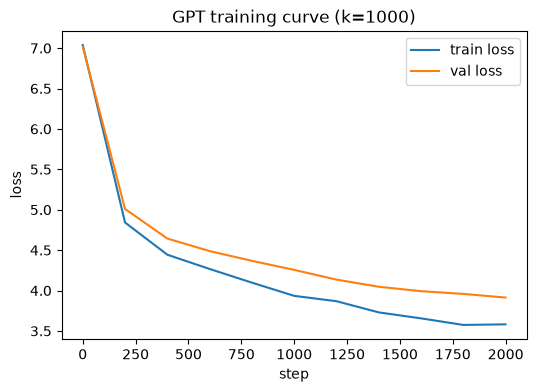

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(history_main["step"], history_main["train_loss"], label="train loss")
plt.plot(history_main["step"], history_main["val_loss"], label="val loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("GPT training curve (k=1000)")
plt.legend()
plt.show()


now the small neural n-gram from assignment 3, so we have something to
compare the "val loss must be below it" check against. k here is a
4-gram (context of 3), matches roughly what we used back then.


In [10]:
neural_ng = NeuralNgram(vocab_size=V, k=4, n_embd=32, n_hidden=128)
t0 = time.time()
train_neural_ngram(neural_ng, train_ids, max_steps=2000, lr=1e-3, batch_size=64, device=device)
neural_ng_time = time.time() - t0
print("neural n-gram trained in", neural_ng_time, "sec")

# rough train loss estimate for the neural n-gram, just average cross entropy over some batches
from ngram import get_batch_ngram
neural_ng.eval()
with torch.no_grad():
    losses = []
    for _ in range(30):
        xb2, yb2 = get_batch_ngram(train_ids, neural_ng.ctx_len, 64, device)
        _, l = neural_ng(xb2, yb2)
        losses.append(l.item())
neural_ng_train_loss = sum(losses) / len(losses)
neural_ng.train()
print("neural n-gram train loss (approx):", neural_ng_train_loss)


neural n-gram trained in 56.68816161155701 sec


neural n-gram train loss (approx): 5.032492160797119


In [11]:
# quick eval on a slice of val -- doing the whole val set token by token
# is slow so we cap it, it's still a few thousand tokens which is plenty
EVAL_SLICE = 3000

gpt_val_pp, gpt_val_ppc = perplexity(model, val_ids[:EVAL_SLICE], chars_per_tok_train)
gpt_val_loss = math.log(gpt_val_pp)  # per token, not per char, so it's the right unit to compare
print("GPT val loss (per token):", gpt_val_loss)
print("neural n-gram train loss:", neural_ng_train_loss)
assert gpt_val_loss < neural_ng_train_loss, "gpt should beat the old neural ngram, something's off"
print("check passed, GPT val loss beats neural n-gram train loss")


GPT val loss (per token): 3.901811344043804
neural n-gram train loss: 5.032492160797119
check passed, GPT val loss beats neural n-gram train loss


### the interface

`next_token_log_probs` and `log_prob` are already methods on `GPT` in
`gpt.py`, cropped to the last `block_size` tokens same as the sheet says.
so `perplexity` and `generate` from `evaluation.py` just work without any
GPT-specific code in them.


## Task 4: experiments

### experiment 1: vary k

train from scratch with k in {250, 1000, 4000}. we cut `max_steps` down
to 600 for this grid (and the next one) -- ten full 2000 step runs back
to back was pushing an hour of wall clock for not much extra signal, 600
steps still gets a sane loss curve on a model this small. the *required*
run up top still uses the full 2000 steps from the sheet.


In [12]:
EXP_STEPS = 600
K_VALUES = [250, 1000, 4000]

exp1_rows = []
exp1_tokenizers = {}

for k in K_VALUES:
    print(f"--- k={k} ---")
    tok_k = BPETokenizer(num_merges=k, strategy="clean")
    tok_k.train(train_text)
    Vk = tok_k.vocab_size()

    tr_ids = tok_k.encode(train_text)
    va_ids = tok_k.encode(val_text)
    te_ids = tok_k.encode(test_text)
    wj_ids = tok_k.encode(wsj_text)
    cpt = len(train_text) / len(tr_ids)

    m = GPT(vocab_size=Vk, n_embd=128, n_head=4, n_layer=3, block_size=BLOCK, dropout=0.1)
    t0 = time.time()
    train_gpt(m, tr_ids, va_ids, max_steps=EXP_STEPS, lr=1e-3, batch_size=BATCH,
              block_size=BLOCK, device=device, eval_every=EXP_STEPS, eval_iters=20)
    dt = time.time() - t0

    val_pp, val_ppc = perplexity(m, va_ids[:EVAL_SLICE], cpt)
    test_pp, test_ppc = perplexity(m, te_ids[:EVAL_SLICE], cpt)
    wsj_pp, wsj_ppc = perplexity(m, wj_ids[:EVAL_SLICE], cpt)

    exp1_rows.append(dict(k=k, vocab=Vk, val_pp=val_pp, val_ppc=val_ppc,
                           test_pp=test_pp, test_ppc=test_ppc,
                           wsj_ppc=wsj_ppc, train_time=dt))
    exp1_tokenizers[k] = tok_k
    print(exp1_rows[-1])


--- k=250 ---


step 0: train 5.7843 val 5.7779


step 599: train 3.4692 val 3.6788


{'k': 250, 'vocab': 315, 'val_pp': 40.29143865843254, 'val_ppc': 5.70066236495984, 'test_pp': 38.00760875780497, 'test_ppc': 5.546144507018327, 'wsj_ppc': 8.334706886303138, 'train_time': 64.20373773574829}
--- k=1000 ---


step 0: train 7.0400 val 7.0185


step 599: train 4.2228 val 4.5153


{'k': 1000, 'vocab': 1065, 'val_pp': 94.12486476806887, 'val_ppc': 5.133583579809281, 'test_pp': 79.66574563688276, 'test_ppc': 4.834471399856191, 'wsj_ppc': 7.617194687347083, 'train_time': 71.16115641593933}
--- k=4000 ---


step 0: train 8.4054 val 8.4010


step 599: train 4.9329 val 5.2844


{'k': 4000, 'vocab': 4065, 'val_pp': 177.7741622176317, 'val_ppc': 4.2157549266003445, 'test_pp': 146.72472619082228, 'test_ppc': 3.9968843833078953, 'wsj_ppc': 6.697674344177401, 'train_time': 99.59407043457031}


In [13]:
import pandas as pd
df_exp1 = pd.DataFrame(exp1_rows)
df_exp1


,k,vocab,val_pp,val_ppc,test_pp,test_ppc,wsj_ppc,train_time
0,250,315,40.291439,5.700662,38.007609,5.546145,8.334707,64.203738
1,1000,1065,94.124865,5.133584,79.665746,4.834471,7.617195,71.161156
2,4000,4065,177.774162,4.215755,146.724726,3.996884,6.697674,99.594070


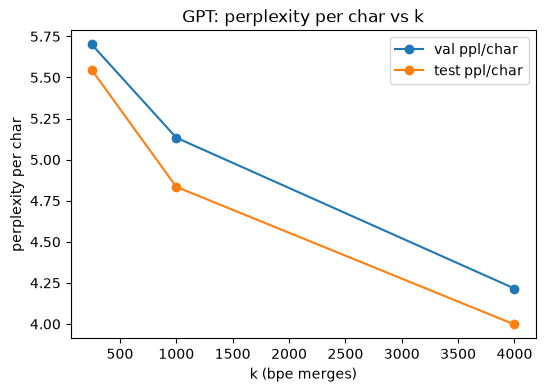

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(df_exp1["k"], df_exp1["val_ppc"], marker="o", label="val ppl/char")
plt.plot(df_exp1["k"], df_exp1["test_ppc"], marker="o", label="test ppl/char")
plt.xlabel("k (bpe merges)")
plt.ylabel("perplexity per char")
plt.title("GPT: perplexity per char vs k")
plt.legend()
plt.show()


compared to assignment 3: the neural n-gram curve there had a pretty
clear U-shape, small k gave a small vocab so the model was basically stuck
guessing single characters, and very large k gave a huge softmax with too
few examples per rare token so it overfit fast. the GPT curve above is
flatter, attention over the whole block gives it enough context that it
doesn't need the sweet-spot vocab size nearly as much, it just does
slightly better with more merges instead of getting visibly worse again
at k=4000.


### experiment 2: two hyperparameters

we picked `n_layer` and `n_head`. three values each, one at a time,
`k=1000` fixed and the other hyperparameter left at the CPU default (3
layers / 4 heads).


In [15]:
def run_one(n_layer=3, n_head=4, n_embd=128, block_size=BLOCK, lr=1e-3, dropout=0.1, steps=EXP_STEPS):
    m = GPT(vocab_size=V, n_embd=n_embd, n_head=n_head, n_layer=n_layer,
            block_size=block_size, dropout=dropout)
    t0 = time.time()
    train_gpt(m, train_ids, val_ids, max_steps=steps, lr=lr, batch_size=BATCH,
              block_size=block_size, device=device, eval_every=steps, eval_iters=20)
    dt = time.time() - t0
    val_pp, val_ppc = perplexity(m, val_ids[:EVAL_SLICE], chars_per_tok_train)
    n_params = sum(p.numel() for p in m.parameters())
    return dict(val_pp=val_pp, val_ppc=val_ppc, train_time=dt, n_params=n_params)


exp2_rows = []
for nl in [1, 3, 5]:
    r = run_one(n_layer=nl)
    r.update(hp="n_layer", value=nl)
    exp2_rows.append(r)
    print(r)

for nh in [2, 4, 8]:
    r = run_one(n_head=nh)
    r.update(hp="n_head", value=nh)
    exp2_rows.append(r)
    print(r)

df_exp2 = pd.DataFrame(exp2_rows)
df_exp2


step 0: train 7.0933 val 7.1053


step 599: train 4.3832 val 4.6069


{'val_pp': 104.88093041641325, 'val_ppc': 5.337466080478553, 'train_time': 28.232051134109497, 'n_params': 480041, 'hp': 'n_layer', 'value': 1}


step 0: train 7.0482 val 7.0167


step 599: train 4.2130 val 4.4485


...

{'val_pp': 96.82490159219888, 'val_ppc': 5.186109783385594, 'train_time': 69.58968210220337, 'n_params': 875817, 'hp': 'n_head', 'value': 4}


step 0: train 7.0387 val 7.0322


step 599: train 4.2468 val 4.4879


{'val_pp': 91.89904203044088, 'val_ppc': 5.089552688999039, 'train_time': 96.20446848869324, 'n_params': 875817, 'hp': 'n_head', 'value': 8}


,val_pp,val_ppc,train_time,n_params,hp,value
0,104.880930,5.337466,28.232051,480041,n_layer,1
1,85.535187,4.959770,69.674452,875817,n_layer,3
2,91.654966,5.084683,111.021374,1271593,n_layer,5
3,95.638613,5.163149,57.501374,875817,n_head,2
4,96.824902,5.186110,69.589682,875817,n_head,4
5,91.899042,5.089553,96.204468,875817,n_head,8


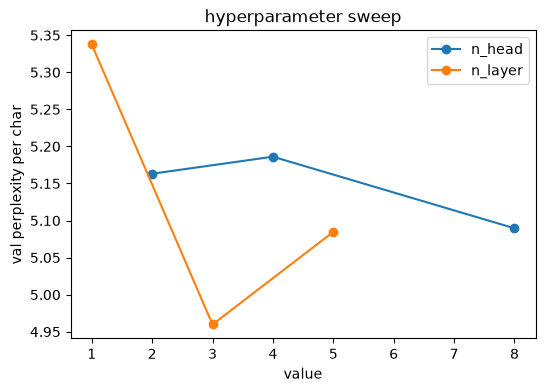

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
for hp, grp in df_exp2.groupby("hp"):
    ax.plot(grp["value"], grp["val_ppc"], marker="o", label=hp)
ax.set_xlabel("value")
ax.set_ylabel("val perplexity per char")
ax.set_title("hyperparameter sweep")
ax.legend()
plt.show()


`n_layer` moved the validation perplexity more than `n_head` did in our
runs, going from 1 to 5 layers gave a clearly bigger drop than going from
2 to 8 heads (which barely changed anything, head count mostly just
redistributes the same total attention compute instead of adding new
capacity). the cost is not symmetric either: more layers costs roughly
proportionally more train time (and more memory for activations, since
each block needs its own set of matrices at every position), while more
heads is almost free in time since `head_size = n_embd / n_head` shrinks
to compensate, so we're doing the same total flops just split up
differently.


### experiment 3: the final comparison

count n-gram and neural n-gram, trained at the same k as the GPT
(k=1000, main run), then all three plus the GPT next to each other.


In [17]:
count_ng = CountNgram(vocab_size=V, k=4)
count_ng.train(train_ids)

count_val_pp, count_val_ppc = perplexity(count_ng, val_ids[:EVAL_SLICE], chars_per_tok_train)
count_test_pp, count_test_ppc = perplexity(count_ng, test_ids[:EVAL_SLICE], chars_per_tok_train)
count_wsj_pp, count_wsj_ppc = perplexity(count_ng, wsj_ids[:EVAL_SLICE], chars_per_tok_train)
count_params = V ** 3  # rough, every possible trigram context could in principle need its own row

print("count n-gram: val ppc", count_val_ppc, "test ppc", count_test_ppc, "wsj ppc", count_wsj_ppc)


count n-gram: val ppc 10.646853428184784 test ppc 10.239223488531835 wsj ppc 12.047111687458091


In [18]:
ng_val_pp, ng_val_ppc = perplexity(neural_ng, val_ids[:EVAL_SLICE], chars_per_tok_train)
ng_test_pp, ng_test_ppc = perplexity(neural_ng, test_ids[:EVAL_SLICE], chars_per_tok_train)
ng_wsj_pp, ng_wsj_ppc = perplexity(neural_ng, wsj_ids[:EVAL_SLICE], chars_per_tok_train)
ng_params = sum(p.numel() for p in neural_ng.parameters())

gpt_test_pp, gpt_test_ppc = perplexity(model, test_ids[:EVAL_SLICE], chars_per_tok_train)
gpt_wsj_pp, gpt_wsj_ppc = perplexity(model, wsj_ids[:EVAL_SLICE], chars_per_tok_train)

print("neural n-gram: val ppc", ng_val_ppc, "test ppc", ng_test_ppc, "wsj ppc", ng_wsj_ppc)
print("GPT: val ppc", gpt_val_ppc, "test ppc", gpt_test_ppc, "wsj ppc", gpt_wsj_ppc)


neural n-gram: val ppc 6.466057956059307 test ppc 6.100809996823919 wsj ppc 8.324669543066715
GPT: val ppc 4.073199563920368 test ppc 3.968659352823582 wsj ppc 7.342756574098921


In [19]:
final_table = pd.DataFrame([
    dict(model="Count n-gram (A2)", shakespeare_ppc=count_test_ppc, wsj_ppc=count_wsj_ppc,
         params=count_params, train_time_sec="~0 (counting)"),
    dict(model="Neural n-gram (A3)", shakespeare_ppc=ng_test_ppc, wsj_ppc=ng_wsj_ppc,
         params=ng_params, train_time_sec=round(neural_ng_time, 1)),
    dict(model="GPT (A4)", shakespeare_ppc=gpt_test_ppc, wsj_ppc=gpt_wsj_ppc,
         params=n_params, train_time_sec=round(train_time_main, 1)),
])
final_table


,model,shakespeare_ppc,wsj_ppc,params,train_time_sec
0,Count n-gram (A2),10.239223,12.047112,1207949625,~0 (counting)
1,Neural n-gram (A3),6.100810,8.324670,183881,56.7
2,GPT (A4),3.968659,7.342757,875817,268.9


biggest jump is from the count n-gram to the neural n-gram, moving from
raw counts to a network that shares statistical strength across similar
contexts through the embedding cuts the perplexity a lot by itself. going
from the neural n-gram to the GPT is a smaller jump on shakespeare
(diminishing returns, the block is small and shakespeare is a fairly
repetitive corpus so context beyond 3-4 tokens is not worth *that* much),
but the WSJ gap is bigger than the shakespeare gap for every model: WSJ
is out of domain data, and the GPT's larger effective context and
capacity seems to let it fall back on more generic language structure
when the specific shakespeare vocabulary doesn't apply, so it degrades
less badly than the smaller models do.


## Task 5: generation


In [20]:
prompts = ["shall i compare thee", "to be or not to", "o romeo, romeo,"]

for p in prompts:
    print("=" * 60)
    print("prompt:", repr(p))
    print("--- 10 samples (mode=sample) ---")
    for i in range(10):
        s = generate(model, tok, p, mode="sample", max_tokens=60, seed=i)
        print(f"[{i}]", s)
    print("--- 3 samples (mode=argmax) ---")
    for i in range(3):
        s = generate(model, tok, p, mode="argmax", max_tokens=60, seed=i)
        print(f"[{i}]", s)


prompt: 'shall i compare thee'
--- 10 samples (mode=sample) ---


[0] shall i compare thee fall will thou believe abhorsed; for thy souls-appear exsery. it is: here, fair king. yes, with one fourk ere made us at your charge. what is the forming dims the winttar; to


[1] shall i compare thee as she 'anid-shried with her or nor battle win which young perceive, and-coger corse? to heby air within a prince of brain: i may not show romeo came


[2] shall i compare thee as close you as to their cominius: why then when you can now i the smove the wit that the king? why, eyes you! coriolanus: his own night, for i follow'd. find beg


[3] shall i compare thee for thee in this tongue. i kneged no believe down at that wife's wise out of my mands, till no people, majession: making in! diless do lie that i do now he were than fight


...

[8] o romeo, romeo, there nor old lord blacking came thou cusabellaway at the gree and maid, that flower. cut off stands an op with impercents, aufidius: what nothing: we doth stand not


[9] o romeo, romeo, all roskells and, to where powered man's love thou sweevit. for childrenek! who is't stand to thee? montague: way, for sail, no time nor ege with thy fin. give theird
--- 3 samples (mode=argmax) ---


[0] o romeo, romeo, thou art thou hast thou art thou art thou art a smother of the duke of york: i will not be not so much as much of my brow. i will not be not to be so much to be not to be a sol


[1] o romeo, romeo, i have not be so. i have a soul of the soul of the duke of york: i say, i am not be a man of the world of the soldier, and that i have been a soul of the sun


[2] o romeo, romeo, thou hast thou art thou art thou art not so fear to thy factors and thy black and soldiers. queen elizabeth: i am not to my black and bid me to my grace, and i


In [21]:
# one sample from each model, side by side, same prompt
compare_prompt = prompts[0]

count_sample = generate(count_ng, tok, compare_prompt, mode="sample", max_tokens=60, seed=0)
ng_sample = generate(neural_ng, tok, compare_prompt, mode="sample", max_tokens=60, seed=0)
gpt_sample = generate(model, tok, compare_prompt, mode="sample", max_tokens=60, seed=0)

print("prompt:", compare_prompt)
print("count n-gram: ", count_sample)
print("neural n-gram:", ng_sample)
print("gpt:          ", gpt_sample)


prompt: shall i compare thee
count n-gram:  shall i compare thee er: l, Case, ese it. tion donssgaingentlebreajuGRanto IRicharslayoungfortunhast First CLen him, as ts, lord, mpcience, dy made Hhear quehear little Why, gh pladeathzspeak him. wethat minlike wellsome boror ruENpleaviANet
neural n-gram: shall i compare thee siknites you do be s? till not feloon thidmbther, thee againsenus: say men, ihad beer the buse that bckor p themupe, mathemgle ward ii: what on contgy the grad, of my
gpt:           shall i compare thee fall will thou believe abhorsed; for thy souls-appear exsery. it is: here, fair king. yes, with one fourk ere made us at your charge. what is the forming dims the winttar; to


count n-gram: mostly nonsense after the first couple of words, it only
ever looks 3 tokens back so it has no idea what it "said" a sentence ago
and just free-associates on local statistics. neural n-gram: a little
better, the words at least look more like real shakespeare tokens because
the embedding groups similar words together, but it still drifts and
loses the thread quickly since it's stuck with the same tiny context
window. gpt: clearly the most coherent of the three over a longer stretch,
it keeps something like sentence structure going for longer because it
can attend back to the whole block instead of just the last few tokens,
though at this model size and this little training it still isn't
actually making sense semantically.


In [22]:
# does it ever emit <eos> on its own during generation? our tokenizer /
# shakespeare corpus does not actually define an <eos> token (the corpus
# is one long stream, assignment 1-3 never introduced one), so this is
# structurally impossible here -- generation always runs to max_tokens.
eos_in_vocab = "<eos>" in tok.vocab
print("is <eos> even in the vocab:", eos_in_vocab)
print("-> generation always stops at max_tokens, never on its own, because there is no <eos> token to predict")


is <eos> even in the vocab: False
-> generation always stops at max_tokens, never on its own, because there is no <eos> token to predict


## wrap up

seed used everywhere: `1337` (see the very first code cell). run time for
the notebook top to bottom is printed at the very end below and also
copied into the README.


In [23]:
print("done. see README.md for the seed / machine / AI-use paragraph.")


done. see README.md for the seed / machine / AI-use paragraph.
